In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/ecommerce_transactions.csv")
df.head()

,order_id,customer_id,order_date,product_id,category,subcategory,brand,quantity,mrp,discount_pct,selling_price,payment_method,city,order_status,return_flag
0,O000001,C01339,2025-01-01,P0107,Beauty,Makeup,Luma,1,1135,25,851.25,UPI,Mumbai,Delivered,No
1,O000002,C11610,2025-10-30,P0417,Women Fashion,Jeans,Nova,1,4701,20,3760.80,Debit Card,Delhi,Delivered,No
2,O000003,C09819,2025-02-12,P0862,Accessories,Sunglasses,NorthStar,1,1693,35,1100.45,UPI,Kolkata,Delivered,No
3,O000004,C06584,2025-09-25,P0506,Men Fashion,Ethnic Wear,Casa,3,737,35,479.05,Debit Card,Pune,Delivered,No
4,O000005,C06496,2025-01-07,P0203,Electronics,Speakers,Aster,1,1793,35,1165.45,UPI,Mumbai,Delivered,No


In [3]:
df.shape

(60120, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60120 entries, 0 to 60119
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        60120 non-null  object 
 1   customer_id     60120 non-null  object 
 2   order_date      60120 non-null  object 
 3   product_id      60120 non-null  object 
 4   category        60120 non-null  object 
 5   subcategory     60120 non-null  object 
 6   brand           60030 non-null  object 
 7   quantity        60120 non-null  int64  
 8   mrp             60120 non-null  int64  
 9   discount_pct    60120 non-null  int64  
 10  selling_price   60120 non-null  float64
 11  payment_method  60030 non-null  object 
 12  city            60120 non-null  object 
 13  order_status    60120 non-null  object 
 14  return_flag     60120 non-null  object 
dtypes: float64(1), int64(3), object(11)
memory usage: 6.9+ MB


In [5]:
df.duplicated().sum()

np.int64(120)

In [6]:
clean_df = df.copy()

In [7]:
clean_df = clean_df.drop_duplicates()

clean_df.shape

(60000, 15)

In [8]:
clean_df["order_date"] = pd.to_datetime(clean_df["order_date"])

clean_df["order_date"].dtype

dtype('<M8[ns]')

In [9]:
clean_df["brand"] = clean_df["brand"].fillna("Unknown")

In [10]:
clean_df["payment_method"] = clean_df["payment_method"].fillna("Unknown")

In [11]:
clean_df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
product_id,0
category,0
subcategory,0
brand,0
quantity,0
mrp,0
discount_pct,0


In [12]:
clean_df[clean_df["quantity"] <= 0]

,order_id,customer_id,order_date,product_id,category,subcategory,brand,quantity,mrp,discount_pct,selling_price,payment_method,city,order_status,return_flag


In [13]:
clean_df[clean_df["selling_price"] <= 0]

,order_id,customer_id,order_date,product_id,category,subcategory,brand,quantity,mrp,discount_pct,selling_price,payment_method,city,order_status,return_flag


### Feature Engineering: Discount Amount

Calculate the total discount amount for each transaction to measure the monetary value of discounts offered to customers.

In [14]:
clean_df["gmv"] = (
    clean_df["selling_price"] *
    clean_df["quantity"]
)

In [15]:
clean_df["discount_amount"] = (
    clean_df["mrp"] - clean_df["selling_price"]
) * clean_df["quantity"]

In [16]:
clean_df["order_month"] = (
    clean_df["order_date"].dt.to_period("M")
)

In [17]:
clean_df["weekday"] = clean_df["order_date"].dt.day_name()

In [18]:
clean_df.head()

,order_id,customer_id,order_date,product_id,category,subcategory,brand,quantity,mrp,discount_pct,selling_price,payment_method,city,order_status,return_flag,gmv,discount_amount,order_month,weekday
0,O000001,C01339,2025-01-01,P0107,Beauty,Makeup,Luma,1,1135,25,851.25,UPI,Mumbai,Delivered,No,851.25,283.75,2025-01,Wednesday
1,O000002,C11610,2025-10-30,P0417,Women Fashion,Jeans,Nova,1,4701,20,3760.80,Debit Card,Delhi,Delivered,No,3760.80,940.20,2025-10,Thursday
2,O000003,C09819,2025-02-12,P0862,Accessories,Sunglasses,NorthStar,1,1693,35,1100.45,UPI,Kolkata,Delivered,No,1100.45,592.55,2025-02,Wednesday
3,O000004,C06584,2025-09-25,P0506,Men Fashion,Ethnic Wear,Casa,3,737,35,479.05,Debit Card,Pune,Delivered,No,1437.15,773.85,2025-09,Thursday
4,O000005,C06496,2025-01-07,P0203,Electronics,Speakers,Aster,1,1793,35,1165.45,UPI,Mumbai,Delivered,No,1165.45,627.55,2025-01,Tuesday


Headline Business KPIs

In [19]:
delivered = clean_df[
    clean_df["order_status"] == "Delivered"
].copy()

In [20]:
total_orders = clean_df["order_id"].nunique()
total_orders

60000

In [21]:
delivered_orders = delivered["order_id"].nunique()
delivered_orders

50501

In [22]:
total_customers = clean_df["customer_id"].nunique()
total_customers

14745

In [23]:
total_gmv = delivered["gmv"].sum()

round(total_gmv, 2)

np.float64(136790302.95)

In [24]:
order_values = (
    delivered
    .groupby("order_id")["gmv"]
    .sum()
)

aov = order_values.mean()

round(aov, 2)

np.float64(2708.67)

In [25]:
order_status = (
    clean_df
    .groupby("order_id")["order_status"]
    .first()
)

cancellation_rate = (
    (order_status == "Cancelled").mean() * 100
)

round(cancellation_rate, 2)

np.float64(7.91)

In [26]:
return_rate = (
    (order_status == "Returned").mean() * 100
)

round(return_rate, 2)

np.float64(7.92)

In [27]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Delivered Orders",
        "Total Customers",
        "GMV",
        "Average Order Value",
        "Cancellation Rate %",
        "Return Rate %"
    ],
    "Value": [
        total_orders,
        delivered_orders,
        total_customers,
        round(total_gmv, 2),
        round(aov, 2),
        round(cancellation_rate, 2),
        round(return_rate, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Orders,6.000000e+04
1,Delivered Orders,5.050100e+04
2,Total Customers,1.474500e+04
3,GMV,1.367903e+08
4,Average Order Value,2.708670e+03
5,Cancellation Rate %,7.910000e+00
6,Return Rate %,7.920000e+00


In [28]:
monthly_gmv = (
    delivered
    .groupby("order_month")["gmv"]
    .sum()
    .reset_index()
)

monthly_gmv

,order_month,gmv
0,2025-01,11616985.15
1,2025-02,10323984.80
2,2025-03,11553682.90
3,2025-04,11286758.35
4,2025-05,11276160.95
5,2025-06,11553073.75
6,2025-07,11776983.45
7,2025-08,11702774.90
8,2025-09,11234474.30
9,2025-10,11583361.25


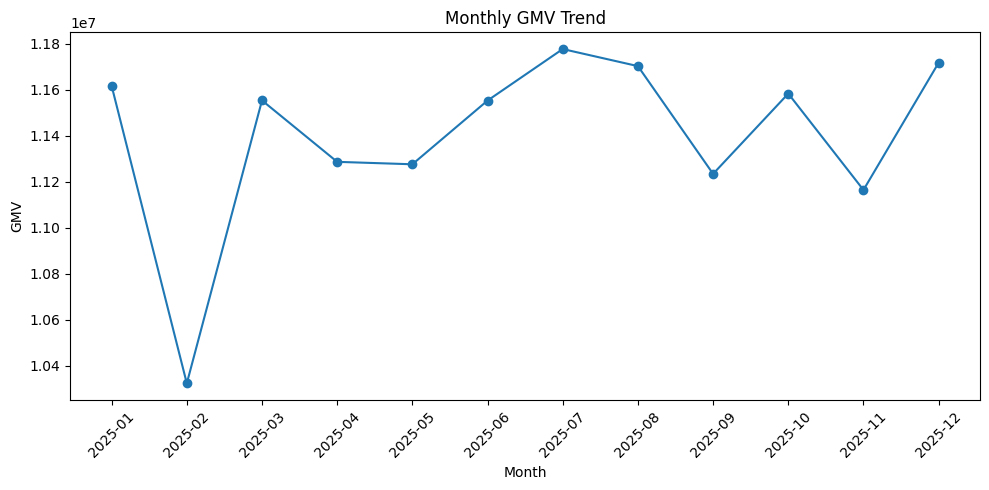

In [29]:
monthly_gmv["order_month"] = monthly_gmv["order_month"].astype(str)

plt.figure(figsize=(10,5))
plt.plot(
    monthly_gmv["order_month"],
    monthly_gmv["gmv"],
    marker="o"
)

plt.title("Monthly GMV Trend")
plt.xlabel("Month")
plt.ylabel("GMV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
category_analysis = (
    delivered
    .groupby("category")
    .agg(
        Orders=("order_id", "nunique"),
        Customers=("customer_id", "nunique"),
        GMV=("gmv", "sum")
    )
    .reset_index()
    .sort_values("GMV", ascending=False)
)

category_analysis

,category,Orders,Customers,GMV
6,Women Fashion,11205,7886,30449458.05
5,Men Fashion,9114,6851,24625031.10
2,Electronics,6630,5356,17737480.65
3,Footwear,6440,5253,17481935.55
1,Beauty,6102,5020,16680854.95
0,Accessories,5959,4896,16028030.50
4,Home,5051,4298,13787512.15


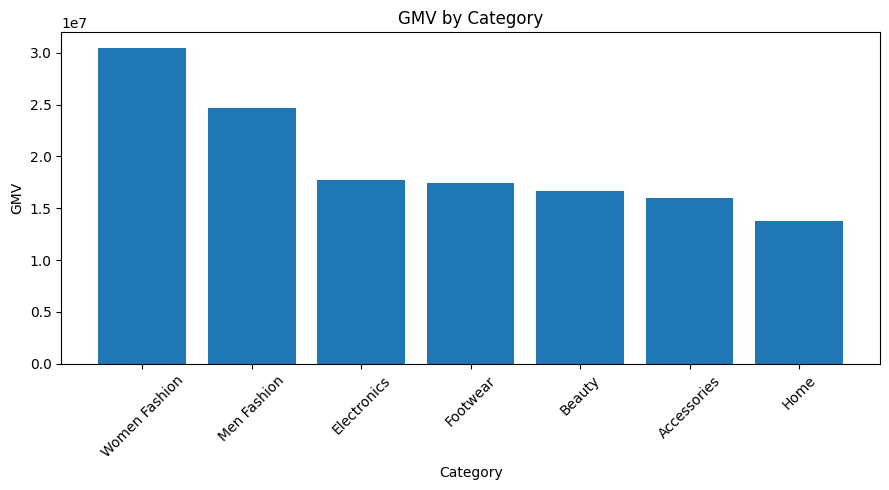

In [31]:
plt.figure(figsize=(9,5))

plt.bar(
    category_analysis["category"],
    category_analysis["GMV"]
)

plt.title("GMV by Category")
plt.xlabel("Category")
plt.ylabel("GMV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
city_analysis = (
    delivered
    .groupby("city")
    .agg(
        Orders=("order_id", "nunique"),
        Customers=("customer_id", "nunique"),
        GMV=("gmv", "sum")
    )
    .reset_index()
    .sort_values("GMV", ascending=False)
)

city_analysis

,city,Orders,Customers,GMV
1,Bengaluru,6320,5181,17341484.70
4,Hyderabad,6396,5228,17340123.95
0,Ahmedabad,6315,5139,17265945.35
5,Kolkata,6324,5195,17191200.50
3,Delhi,6238,5099,17041774.25
7,Pune,6272,5091,16958541.90
2,Chennai,6342,5209,16854673.30
6,Mumbai,6294,5122,16796559.00


In [33]:
category_status = (
    clean_df
    .groupby("category")
    .agg(
        Total_Orders=("order_id", "nunique"),
        Returned_Orders=(
            "order_status",
            lambda x: (x == "Returned").sum()
        )
    )
    .reset_index()
)

category_status["Return_Rate_%"] = (
    category_status["Returned_Orders"] /
    category_status["Total_Orders"] *
    100
)

category_status.sort_values(
    "Return_Rate_%",
    ascending=False
)

,category,Total_Orders,Returned_Orders,Return_Rate_%
3,Footwear,7757,671,8.650251
5,Men Fashion,10852,878,8.090675
1,Beauty,7252,579,7.984004
0,Accessories,7053,563,7.982419
4,Home,6016,474,7.878989
6,Women Fashion,13240,1008,7.613293
2,Electronics,7830,582,7.432950


In [34]:
customer_frequency = (
    delivered
    .groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

customer_frequency.head()

,customer_id,order_count
0,C00001,6
1,C00002,2
2,C00003,6
3,C00004,1
4,C00005,3


In [35]:
repeat_customers = customer_frequency[
    customer_frequency["order_count"] > 1
]

repeat_customers.head()

,customer_id,order_count
0,C00001,6
1,C00002,2
2,C00003,6
4,C00005,3
5,C00006,2


In [36]:
repeat_rate = (
    len(repeat_customers) /
    len(customer_frequency) *
    100
)

round(repeat_rate, 2)

87.8

In [37]:
def purchase_group(x):
    if x == 1:
        return "1 Order"
    elif x == 2:
        return "2 Orders"
    elif x <= 5:
        return "3-5 Orders"
    else:
        return "6+ Orders"

customer_frequency["purchase_group"] = (
    customer_frequency["order_count"]
    .apply(purchase_group)
)


In [38]:
purchase_distribution = (
    customer_frequency["purchase_group"]
    .value_counts()
)

purchase_distribution

,count
purchase_group,
3-5 Orders,7933
2 Orders,2917
6+ Orders,1863
1 Order,1766


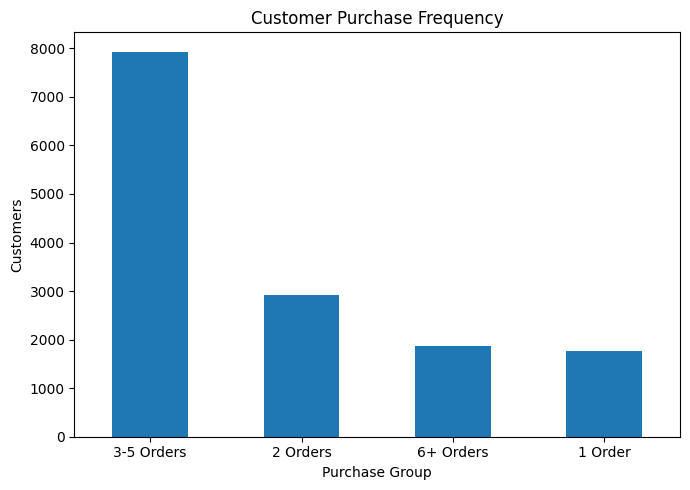

In [39]:
plt.figure(figsize=(7,5))
purchase_distribution.plot(kind="bar")

plt.title("Customer Purchase Frequency")
plt.xlabel("Purchase Group")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Cohort Retention Analysis

Cohort analysis groups customers based on the month of their first purchase and tracks their purchasing activity over subsequent months.

This analysis helps identify how effectively the business retains newly acquired customers over time.

In [40]:
delivered["order_month"] = (
    delivered["order_date"].dt.to_period("M")
)

In [41]:
delivered["cohort_month"] = (
    delivered
    .groupby("customer_id")["order_date"]
    .transform("min")
    .dt.to_period("M")
)

In [42]:
delivered[
    ["customer_id", "order_date", "order_month", "cohort_month"]
].head(10)

,customer_id,order_date,order_month,cohort_month
0,C01339,2025-01-01,2025-01,2025-01
1,C11610,2025-10-30,2025-10,2025-03
2,C09819,2025-02-12,2025-02,2025-02
3,C06584,2025-09-25,2025-09,2025-09
4,C06496,2025-01-07,2025-01,2025-01
5,C12879,2025-11-12,2025-11,2025-06
6,C01290,2025-04-02,2025-04,2025-02
7,C10461,2025-12-12,2025-12,2025-09
8,C03023,2025-06-22,2025-06,2025-01
9,C01413,2025-07-25,2025-07,2025-04


In [43]:
delivered["cohort_index"] = (
    (delivered["order_month"].dt.year -
     delivered["cohort_month"].dt.year) * 12
    +
    (delivered["order_month"].dt.month -
     delivered["cohort_month"].dt.month)
)

In [44]:
delivered[
    ["customer_id", "order_month", "cohort_month", "cohort_index"]
].head()

,customer_id,order_month,cohort_month,cohort_index
0,C01339,2025-01,2025-01,0
1,C11610,2025-10,2025-03,7
2,C09819,2025-02,2025-02,0
3,C06584,2025-09,2025-09,0
4,C06496,2025-01,2025-01,0


In [45]:
cohort_data = (
    delivered
    .groupby(["cohort_month", "cohort_index"])
    ["customer_id"]
    .nunique()
    .reset_index()
)

cohort_data.head()

,cohort_month,cohort_index,customer_id
0,2025-01,0,3671
1,2025-01,1,822
2,2025-01,2,914
3,2025-01,3,947
4,2025-01,4,876


In [46]:
cohort_counts = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

cohort_counts

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2025-01,3671.0,822.0,914.0,947.0,876.0,897.0,902.0,937.0,895.0,910.0,866.0,928.0
2025-02,2590.0,643.0,665.0,615.0,661.0,651.0,677.0,622.0,613.0,596.0,640.0,NaN
2025-03,2180.0,523.0,560.0,573.0,551.0,526.0,565.0,535.0,523.0,575.0,NaN,NaN
2025-04,1517.0,337.0,369.0,391.0,404.0,351.0,367.0,373.0,351.0,NaN,NaN,NaN
2025-05,1238.0,300.0,313.0,312.0,296.0,315.0,298.0,316.0,NaN,NaN,NaN,NaN
2025-06,927.0,242.0,201.0,228.0,220.0,216.0,223.0,NaN,NaN,NaN,NaN,NaN
2025-07,734.0,196.0,192.0,189.0,178.0,175.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,522.0,122.0,121.0,122.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,388.0,107.0,71.0,93.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
cohort_size = cohort_counts.iloc[:, 0]

retention = (
    cohort_counts
    .divide(cohort_size, axis=0)
    * 100
)

retention.round(1)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2025-01,100.0,22.4,24.9,25.8,23.9,24.4,24.6,25.5,24.4,24.8,23.6,25.3
2025-02,100.0,24.8,25.7,23.7,25.5,25.1,26.1,24.0,23.7,23.0,24.7,NaN
2025-03,100.0,24.0,25.7,26.3,25.3,24.1,25.9,24.5,24.0,26.4,NaN,NaN
2025-04,100.0,22.2,24.3,25.8,26.6,23.1,24.2,24.6,23.1,NaN,NaN,NaN
2025-05,100.0,24.2,25.3,25.2,23.9,25.4,24.1,25.5,NaN,NaN,NaN,NaN
2025-06,100.0,26.1,21.7,24.6,23.7,23.3,24.1,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,26.7,26.2,25.7,24.3,23.8,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,23.4,23.2,23.4,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,27.6,18.3,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


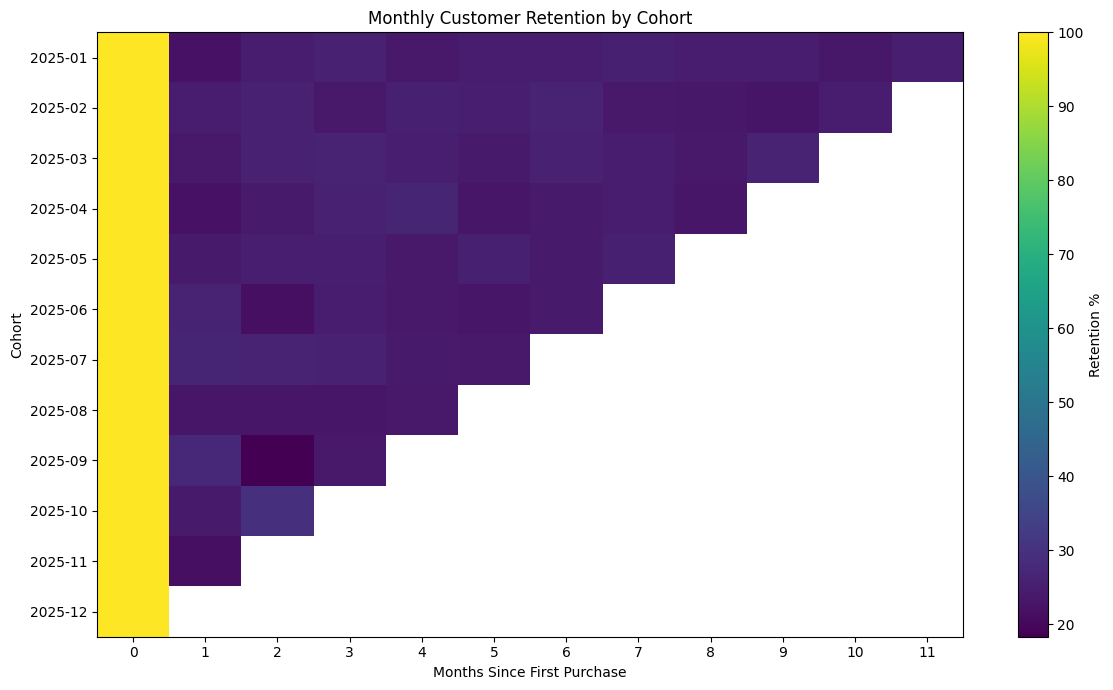

In [48]:
plt.figure(figsize=(12,7))

plt.imshow(
    retention,
    aspect="auto"
)

plt.colorbar(label="Retention %")

plt.title("Monthly Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort")

plt.xticks(
    range(len(retention.columns)),
    retention.columns
)

plt.yticks(
    range(len(retention.index)),
    retention.index.astype(str)
)

plt.tight_layout()
plt.show()

In [49]:
analysis_date = (
    delivered["order_date"].max()
    + pd.Timedelta(days=1)
)

analysis_date

Timestamp('2026-01-01 00:00:00')

## RFM Customer Segmentation

RFM analysis segments customers using three dimensions:

- Recency: How recently the customer purchased
- Frequency: How often the customer purchased
- Monetary Value: How much the customer spent

The objective is to identify high-value, loyal, potential, at-risk, and inactive customer groups that may require different retention strategies.

In [50]:
rfm = (
    delivered
    .groupby("customer_id")
    .agg(
        Recency=(
            "order_date",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=("order_id", "nunique"),
        Monetary=("gmv", "sum")
    )
)

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
C00001,13,6,9924.75
C00002,167,2,1455.75
C00003,111,6,20321.50
C00004,193,1,2219.20
C00005,19,3,5635.90


In [51]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [52]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [53]:
def segment_customer(row):

    if (
        row["R_Score"] >= 4 and
        row["F_Score"] >= 4 and
        row["M_Score"] >= 4
    ):
        return "Champions"

    elif (
        row["R_Score"] >= 3 and
        row["F_Score"] >= 3
    ):
        return "Loyal Customers"

    elif (
        row["R_Score"] >= 4 and
        row["F_Score"] <= 3
    ):
        return "Potential Loyalists"

    elif (
        row["R_Score"] <= 2 and
        row["F_Score"] >= 3
    ):
        return "At Risk"

    else:
        return "Hibernating"

In [54]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
customer_id,,,,,,,
C00001,13,6,9924.75,5,5,4,Champions
C00002,167,2,1455.75,1,1,1,Hibernating
C00003,111,6,20321.50,2,5,5,At Risk
C00004,193,1,2219.20,1,1,1,Hibernating
C00005,19,3,5635.90,5,2,2,Potential Loyalists


In [55]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("Segment", "size"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

segment_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At Risk,2399,149.303460,4.123385,11187.593810
1,Champions,2363,23.593314,5.668218,16818.850804
2,Hibernating,4335,171.321107,1.814994,4878.853956
3,Loyal Customers,3925,48.598981,4.149809,10336.630548
4,Potential Loyalists,1457,25.960879,2.099520,5825.129822


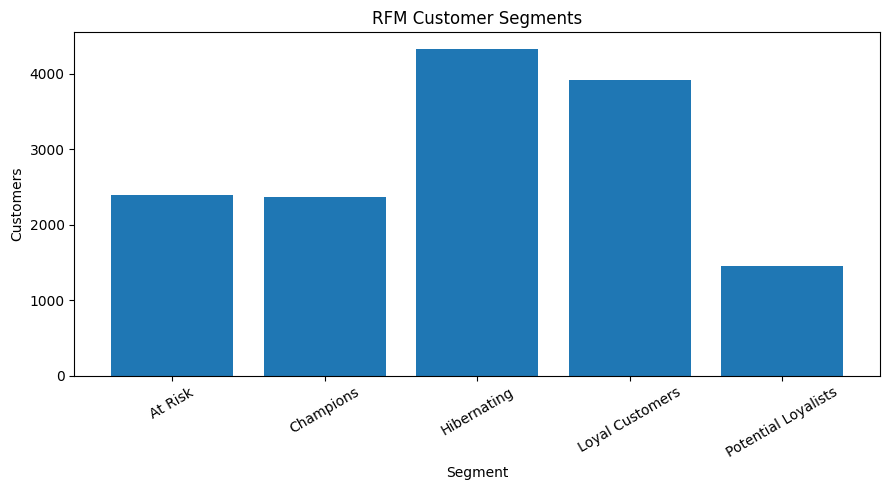

In [56]:
plt.figure(figsize=(9,5))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.title("RFM Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [57]:
delivered["discount_bucket"] = pd.cut(
    delivered["discount_pct"],
    bins=[-1, 10, 20, 30, 40, 100],
    labels=[
        "0-10%",
        "11-20%",
        "21-30%",
        "31-40%",
        "40%+"
    ]
)

In [58]:
discount_analysis = (
    delivered
    .groupby("discount_bucket", observed=False)
    .agg(
        Orders=("order_id", "nunique"),
        Customers=("customer_id", "nunique"),
        GMV=("gmv", "sum")
    )
    .reset_index()
)

discount_analysis

,discount_bucket,Orders,Customers,GMV
0,0-10%,8687,6616,29833630.10
1,11-20%,12630,8447,37880490.05
2,21-30%,14654,9356,39289673.60
3,31-40%,8956,6726,20357249.00
4,40%+,5574,4659,9429260.20


In [59]:
clean_df.to_csv(
    "ecommerce_cleaned.csv",
    index=False
)

In [60]:
retention.to_csv(
    "cohort_retention.csv"
)

In [61]:
rfm.to_csv(
    "rfm_segments.csv"
)

In [62]:
kpi_summary.to_csv(
    "kpi_summary.csv",
    index=False
)

In [63]:
from google.colab import files

files.download("ecommerce_cleaned.csv")
files.download("cohort_retention.csv")
files.download("rfm_segments.csv")
files.download("kpi_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SQL Business Analysis

After completing the exploratory and customer-level analysis in Python, I used SQL to answer key business questions from the cleaned e-commerce transaction data.

The SQL analysis focuses on revenue trends, category performance, customer purchasing behaviour, repeat customers, product performance, and month-over-month growth.

### Key SQL Concepts Used
- GROUP BY
- Aggregate Functions
- CASE WHEN
- Common Table Expressions (CTEs)
- Window Functions
- LAG()
- DENSE_RANK()

In [65]:
import sqlite3

# Create a SQL-friendly copy
sql_df = clean_df.copy()

# Convert Period datatype to string before loading into SQLite
sql_df["order_month"] = sql_df["order_month"].astype(str)

# Create SQLite database connection
conn = sqlite3.connect("ecommerce_analysis.db")

# Load cleaned data into SQL table
sql_df.to_sql(
    "ecommerce_orders",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully.")

Database created successfully.


In [66]:
query = """
SELECT *
FROM ecommerce_orders
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,order_id,customer_id,order_date,product_id,category,subcategory,brand,quantity,mrp,discount_pct,selling_price,payment_method,city,order_status,return_flag,gmv,discount_amount,order_month,weekday
0,O000001,C01339,2025-01-01 00:00:00,P0107,Beauty,Makeup,Luma,1,1135,25,851.25,UPI,Mumbai,Delivered,No,851.25,283.75,2025-01,Wednesday
1,O000002,C11610,2025-10-30 00:00:00,P0417,Women Fashion,Jeans,Nova,1,4701,20,3760.80,Debit Card,Delhi,Delivered,No,3760.80,940.20,2025-10,Thursday
2,O000003,C09819,2025-02-12 00:00:00,P0862,Accessories,Sunglasses,NorthStar,1,1693,35,1100.45,UPI,Kolkata,Delivered,No,1100.45,592.55,2025-02,Wednesday
3,O000004,C06584,2025-09-25 00:00:00,P0506,Men Fashion,Ethnic Wear,Casa,3,737,35,479.05,Debit Card,Pune,Delivered,No,1437.15,773.85,2025-09,Thursday
4,O000005,C06496,2025-01-07 00:00:00,P0203,Electronics,Speakers,Aster,1,1793,35,1165.45,UPI,Mumbai,Delivered,No,1165.45,627.55,2025-01,Tuesday


## SQL Question 1: How does GMV change month over month?

Monthly GMV helps evaluate overall business performance and identify periods of growth or decline. Only delivered orders are included in the GMV calculation.

In [67]:
query = """
SELECT
    substr(order_date, 1, 7) AS month,
    ROUND(SUM(gmv), 2) AS total_gmv
FROM ecommerce_orders
WHERE order_status = 'Delivered'
GROUP BY month
ORDER BY month;
"""

monthly_gmv_sql = pd.read_sql_query(query, conn)

monthly_gmv_sql

,month,total_gmv
0,2025-01,11616985.15
1,2025-02,10323984.80
2,2025-03,11553682.90
3,2025-04,11286758.35
4,2025-05,11276160.95
5,2025-06,11553073.75
6,2025-07,11776983.45
7,2025-08,11702774.90
8,2025-09,11234474.30
9,2025-10,11583361.25


## SQL Question 2: Which product categories generate the highest GMV?

Category-level analysis helps identify the product groups contributing the most to overall sales and customer demand.

In [68]:
query = """
SELECT
    category,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS total_customers,
    ROUND(SUM(gmv), 2) AS total_gmv
FROM ecommerce_orders
WHERE order_status = 'Delivered'
GROUP BY category
ORDER BY total_gmv DESC;
"""

category_sql = pd.read_sql_query(query, conn)

category_sql

,category,total_orders,total_customers,total_gmv
0,Women Fashion,11205,7886,30449458.05
1,Men Fashion,9114,6851,24625031.10
2,Electronics,6630,5356,17737480.65
3,Footwear,6440,5253,17481935.55
4,Beauty,6102,5020,16680854.95
5,Accessories,5959,4896,16028030.50
6,Home,5051,4298,13787512.15


## SQL Question 3: Which categories have the highest Average Order Value?

Average Order Value provides a different perspective from total GMV by showing the typical value generated per transaction within each category.

In [69]:
query = """
WITH order_values AS (
    SELECT
        category,
        order_id,
        SUM(gmv) AS order_value
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY category, order_id
)

SELECT
    category,
    ROUND(AVG(order_value), 2) AS avg_order_value
FROM order_values
GROUP BY category
ORDER BY avg_order_value DESC;
"""

category_aov = pd.read_sql_query(query, conn)

category_aov

,category,avg_order_value
0,Beauty,2733.67
1,Home,2729.66
2,Women Fashion,2717.49
3,Footwear,2714.59
4,Men Fashion,2701.89
5,Accessories,2689.72
6,Electronics,2675.34


## SQL Question 4: Who are the highest-value customers?

Identifying high-value customers helps determine which customers contribute the most GMV and may be important candidates for loyalty and retention initiatives.

In [70]:
query = """
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(gmv), 2) AS total_gmv
FROM ecommerce_orders
WHERE order_status = 'Delivered'
GROUP BY customer_id
ORDER BY total_gmv DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query, conn)

top_customers

,customer_id,total_orders,total_gmv
0,C01698,7,51777.35
1,C07295,7,45630.50
2,C12682,9,43696.85
3,C13540,8,41825.80
4,C11030,7,41167.30
5,C12755,6,40337.05
6,C14465,10,40082.00
7,C00537,6,39239.50
8,C08082,8,38770.05
9,C00309,8,37921.65


## SQL Question 5: How many customers made repeat purchases?

A repeat customer is defined as a customer who completed more than one delivered order during the analysis period. Repeat purchasing provides an important indication of customer retention.

In [71]:
query = """
WITH customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
)

SELECT
    COUNT(*) AS repeat_customers
FROM customer_orders
WHERE order_count > 1;
"""

repeat_sql = pd.read_sql_query(query, conn)

repeat_sql

,repeat_customers
0,12713


## SQL Question 6: What percentage of purchasing customers are repeat customers?

The repeat customer rate measures the proportion of customers who returned to complete another purchase.

In [72]:
query = """
WITH customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
),

customer_summary AS (
    SELECT
        COUNT(*) AS total_customers,
        SUM(
            CASE
                WHEN order_count > 1 THEN 1
                ELSE 0
            END
        ) AS repeat_customers
    FROM customer_orders
)

SELECT
    total_customers,
    repeat_customers,
    ROUND(
        repeat_customers * 100.0 / total_customers,
        2
    ) AS repeat_customer_rate_pct
FROM customer_summary;
"""

repeat_rate_sql = pd.read_sql_query(query, conn)

repeat_rate_sql

,total_customers,repeat_customers,repeat_customer_rate_pct
0,14479,12713,87.8


## SQL Question 7: What is the distribution of one-time and repeat customers?

This analysis helps determine whether the customer base is dominated by single-purchase customers or customers who return for additional purchases.

In [73]:
query = """
WITH customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time Customer'
        ELSE 'Repeat Customer'
    END AS customer_type,
    COUNT(*) AS customers
FROM customer_orders
GROUP BY customer_type;
"""

customer_type_sql = pd.read_sql_query(query, conn)

customer_type_sql

,customer_type,customers
0,One-time Customer,1766
1,Repeat Customer,12713


## SQL Question 7: What is the distribution of one-time and repeat customers?

This analysis helps determine whether the customer base is dominated by single-purchase customers or customers who return for additional purchases.

In [74]:
query = """
WITH customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time Customer'
        ELSE 'Repeat Customer'
    END AS customer_type,
    COUNT(*) AS customers
FROM customer_orders
GROUP BY customer_type;
"""

customer_type_sql = pd.read_sql_query(query, conn)

customer_type_sql

,customer_type,customers
0,One-time Customer,1766
1,Repeat Customer,12713


## SQL Question 8: Which categories have the highest return rates?

Strong sales do not necessarily translate into high-quality revenue. Categories with elevated return rates may create additional fulfilment costs and reduce realized revenue.

In [75]:
query = """
SELECT
    category,
    COUNT(DISTINCT order_id) AS total_orders,

    COUNT(
        DISTINCT CASE
            WHEN order_status = 'Returned'
            THEN order_id
        END
    ) AS returned_orders,

    ROUND(
        COUNT(
            DISTINCT CASE
                WHEN order_status = 'Returned'
                THEN order_id
            END
        ) * 100.0 /
        COUNT(DISTINCT order_id),
        2
    ) AS return_rate_pct

FROM ecommerce_orders

GROUP BY category
ORDER BY return_rate_pct DESC;
"""

category_returns = pd.read_sql_query(query, conn)

category_returns

,category,total_orders,returned_orders,return_rate_pct
0,Footwear,7757,671,8.65
1,Men Fashion,10852,878,8.09
2,Beauty,7252,579,7.98
3,Accessories,7053,563,7.98
4,Home,6016,474,7.88
5,Women Fashion,13240,1008,7.61
6,Electronics,7830,582,7.43


## SQL Question 9: Which categories experience the highest cancellation rates?

Cancellation patterns can highlight areas requiring further investigation, including product availability, pricing, customer intent, or fulfilment issues.

In [76]:
query = """
SELECT
    category,
    COUNT(DISTINCT order_id) AS total_orders,

    COUNT(
        DISTINCT CASE
            WHEN order_status = 'Cancelled'
            THEN order_id
        END
    ) AS cancelled_orders,

    ROUND(
        COUNT(
            DISTINCT CASE
                WHEN order_status = 'Cancelled'
                THEN order_id
            END
        ) * 100.0 /
        COUNT(DISTINCT order_id),
        2
    ) AS cancellation_rate_pct

FROM ecommerce_orders

GROUP BY category
ORDER BY cancellation_rate_pct DESC;
"""

category_cancellation = pd.read_sql_query(query, conn)

category_cancellation

,category,total_orders,cancelled_orders,cancellation_rate_pct
0,Footwear,7757,646,8.33
1,Home,6016,491,8.16
2,Men Fashion,10852,860,7.92
3,Electronics,7830,618,7.89
4,Beauty,7252,571,7.87
5,Women Fashion,13240,1027,7.76
6,Accessories,7053,531,7.53


## SQL Question 10: Which cities contribute the most GMV?

Geographic analysis helps identify markets with relatively strong order volume, customer activity, and GMV contribution.

In [77]:
query = """
SELECT
    city,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(SUM(gmv), 2) AS total_gmv
FROM ecommerce_orders
WHERE order_status = 'Delivered'
GROUP BY city
ORDER BY total_gmv DESC;
"""

city_sql = pd.read_sql_query(query, conn)

city_sql

,city,total_orders,customers,total_gmv
0,Bengaluru,6320,5181,17341484.70
1,Hyderabad,6396,5228,17340123.95
2,Ahmedabad,6315,5139,17265945.35
3,Kolkata,6324,5195,17191200.50
4,Delhi,6238,5099,17041774.25
5,Pune,6272,5091,16958541.90
6,Chennai,6342,5209,16854673.30
7,Mumbai,6294,5122,16796559.00


## SQL Question 11: Which products generate the highest GMV within each category?

Instead of ranking products only at the overall business level, products are ranked within their respective categories.

DENSE_RANK is used to identify the top three products by GMV within each category.

In [78]:
query = """
WITH product_sales AS (
    SELECT
        category,
        product_id,
        ROUND(SUM(gmv), 2) AS total_gmv
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY category, product_id
),

ranked_products AS (
    SELECT
        category,
        product_id,
        total_gmv,

        DENSE_RANK() OVER (
            PARTITION BY category
            ORDER BY total_gmv DESC
        ) AS product_rank

    FROM product_sales
)

SELECT
    category,
    product_id,
    total_gmv,
    product_rank
FROM ranked_products
WHERE product_rank <= 3
ORDER BY category, product_rank;
"""

top_products = pd.read_sql_query(query, conn)

top_products

,category,product_id,total_gmv,product_rank
0,Accessories,P0962,47447.00,1
1,Accessories,P1159,44499.60,2
2,Accessories,P0259,42869.80,3
3,Beauty,P0086,45515.80,1
4,Beauty,P0390,41741.20,2
5,Beauty,P1194,41671.45,3
6,Electronics,P0427,50075.75,1
7,Electronics,P0098,48810.30,2
8,Electronics,P0740,45525.55,3
9,Footwear,P0189,45265.35,1


## SQL Question 12: How does the number of active purchasing customers change over time?

Monthly active purchasing customers help determine whether sales performance is being supported by a growing or declining active customer base.

In [79]:
query = """
SELECT
    substr(order_date, 1, 7) AS month,
    COUNT(DISTINCT customer_id) AS active_customers
FROM ecommerce_orders
WHERE order_status = 'Delivered'
GROUP BY month
ORDER BY month;
"""

monthly_customers = pd.read_sql_query(query, conn)

monthly_customers

,month,active_customers
0,2025-01,3671
1,2025-02,3412
2,2025-03,3737
3,2025-04,3652
4,2025-05,3626
5,2025-06,3727
6,2025-07,3784
7,2025-08,3775
8,2025-09,3659
9,2025-10,3688


## SQL Question 13: What percentage of total GMV does each category contribute?

GMV contribution analysis shows how dependent the business is on individual product categories.

In [80]:
query = """
WITH category_sales AS (
    SELECT
        category,
        SUM(gmv) AS category_gmv
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY category
)

SELECT
    category,
    ROUND(category_gmv, 2) AS category_gmv,

    ROUND(
        category_gmv * 100.0 /
        SUM(category_gmv) OVER (),
        2
    ) AS gmv_contribution_pct

FROM category_sales
ORDER BY category_gmv DESC;
"""

category_contribution = pd.read_sql_query(query, conn)

category_contribution

,category,category_gmv,gmv_contribution_pct
0,Women Fashion,30449458.05,22.26
1,Men Fashion,24625031.10,18.00
2,Electronics,17737480.65,12.97
3,Footwear,17481935.55,12.78
4,Beauty,16680854.95,12.19
5,Accessories,16028030.50,11.72
6,Home,13787512.15,10.08


## SQL Question 14: How does performance vary across discount levels?

This analysis compares order volume, customers, and GMV across different discount ranges.

The results represent observed associations and should not be interpreted as evidence that discounting directly caused changes in purchasing behaviour.

In [81]:
query = """
SELECT
    CASE
        WHEN discount_pct <= 10 THEN '0-10%'
        WHEN discount_pct <= 20 THEN '11-20%'
        WHEN discount_pct <= 30 THEN '21-30%'
        WHEN discount_pct <= 40 THEN '31-40%'
        ELSE '40%+'
    END AS discount_bucket,

    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS customers,
    ROUND(SUM(gmv), 2) AS total_gmv

FROM ecommerce_orders

WHERE order_status = 'Delivered'

GROUP BY discount_bucket
ORDER BY total_gmv DESC;
"""

discount_sql = pd.read_sql_query(query, conn)

discount_sql

,discount_bucket,total_orders,customers,total_gmv
0,21-30%,14654,9356,39289673.60
1,11-20%,12630,8447,37880490.05
2,0-10%,8687,6616,29833630.10
3,31-40%,8956,6726,20357249.00
4,40%+,5574,4659,9429260.20


## SQL Question 15: How does GMV grow or decline month over month?

Month-over-month growth measures the percentage change in GMV relative to the previous month.

The LAG window function is used to retrieve the previous month's GMV and calculate the growth rate.

In [82]:
query = """
WITH monthly_sales AS (
    SELECT
        substr(order_date, 1, 7) AS month,
        SUM(gmv) AS total_gmv
    FROM ecommerce_orders
    WHERE order_status = 'Delivered'
    GROUP BY month
),

monthly_comparison AS (
    SELECT
        month,
        total_gmv,

        LAG(total_gmv) OVER (
            ORDER BY month
        ) AS previous_month_gmv

    FROM monthly_sales
)

SELECT
    month,

    ROUND(total_gmv, 2) AS total_gmv,

    ROUND(
        previous_month_gmv,
        2
    ) AS previous_month_gmv,

    ROUND(
        (total_gmv - previous_month_gmv)
        * 100.0 /
        previous_month_gmv,
        2
    ) AS mom_growth_pct

FROM monthly_comparison
ORDER BY month;
"""

mom_growth = pd.read_sql_query(query, conn)

mom_growth

,month,total_gmv,previous_month_gmv,mom_growth_pct
0,2025-01,11616985.15,NaN,NaN
1,2025-02,10323984.80,11616985.15,-11.13
2,2025-03,11553682.90,10323984.80,11.91
3,2025-04,11286758.35,11553682.90,-2.31
4,2025-05,11276160.95,11286758.35,-0.09
5,2025-06,11553073.75,11276160.95,2.46
6,2025-07,11776983.45,11553073.75,1.94
7,2025-08,11702774.90,11776983.45,-0.63
8,2025-09,11234474.30,11702774.90,-4.00
9,2025-10,11583361.25,11234474.30,3.11


## SQL Analysis Summary

The SQL analysis extended the customer-level analysis by examining business performance from multiple perspectives.

Key areas analyzed included:

- Monthly GMV and month-over-month growth
- Category and geographic performance
- Average Order Value by category
- High-value and repeat customers
- Return and cancellation rates
- Product-level performance within categories
- Category contribution to overall GMV
- Performance across discount ranges

Advanced SQL concepts including CTEs, CASE WHEN, DENSE_RANK, LAG, PARTITION BY, and window aggregations were used to answer the business questions.

# Exporting Analysis for Excel

The key analytical outputs from Python and SQL are exported into a structured Excel workbook.

The workbook will be used to create the final cohort heatmap, customer segmentation summary, KPI presentation, and business insights.

In [83]:
with pd.ExcelWriter(
    "Ecommerce_Retention_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    kpi_summary.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    retention.round(2).to_excel(
        writer,
        sheet_name="Cohort Retention"
    )

    rfm.reset_index().to_excel(
        writer,
        sheet_name="RFM Customers",
        index=False
    )

    segment_summary.to_excel(
        writer,
        sheet_name="RFM Summary",
        index=False
    )

    category_sql.to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    category_returns.to_excel(
        writer,
        sheet_name="Returns",
        index=False
    )

    category_cancellation.to_excel(
        writer,
        sheet_name="Cancellations",
        index=False
    )

    discount_sql.to_excel(
        writer,
        sheet_name="Discount Analysis",
        index=False
    )

    mom_growth.to_excel(
        writer,
        sheet_name="Monthly Growth",
        index=False
    )

    top_products.to_excel(
        writer,
        sheet_name="Top Products",
        index=False
    )

print("Excel workbook created successfully.")

Excel workbook created successfully.


## Download Final Excel Analysis

The structured analytical workbook is downloaded for final formatting, visualization, and business presentation.

In [84]:
from google.colab import files

files.download("Ecommerce_Retention_Analysis.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
print("===== KPI SUMMARY =====")
display(kpi_summary)

print("\n===== COHORT RETENTION =====")
display(retention.round(1))

print("\n===== RFM SEGMENT SUMMARY =====")
display(segment_summary)

print("\n===== CATEGORY RETURNS =====")
display(category_returns)

print("\n===== DISCOUNT ANALYSIS =====")
display(discount_sql)

print("\n===== MONTHLY GMV GROWTH =====")
display(mom_growth)

===== KPI SUMMARY =====


,KPI,Value
0,Total Orders,6.000000e+04
1,Delivered Orders,5.050100e+04
2,Total Customers,1.474500e+04
3,GMV,1.367903e+08
4,Average Order Value,2.708670e+03
5,Cancellation Rate %,7.910000e+00
6,Return Rate %,7.920000e+00



===== COHORT RETENTION =====


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2025-01,100.0,22.4,24.9,25.8,23.9,24.4,24.6,25.5,24.4,24.8,23.6,25.3
2025-02,100.0,24.8,25.7,23.7,25.5,25.1,26.1,24.0,23.7,23.0,24.7,NaN
2025-03,100.0,24.0,25.7,26.3,25.3,24.1,25.9,24.5,24.0,26.4,NaN,NaN
2025-04,100.0,22.2,24.3,25.8,26.6,23.1,24.2,24.6,23.1,NaN,NaN,NaN
2025-05,100.0,24.2,25.3,25.2,23.9,25.4,24.1,25.5,NaN,NaN,NaN,NaN
2025-06,100.0,26.1,21.7,24.6,23.7,23.3,24.1,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,26.7,26.2,25.7,24.3,23.8,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,23.4,23.2,23.4,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,27.6,18.3,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== RFM SEGMENT SUMMARY =====


...

,category,total_orders,returned_orders,return_rate_pct
0,Footwear,7757,671,8.65
1,Men Fashion,10852,878,8.09
2,Beauty,7252,579,7.98
3,Accessories,7053,563,7.98
4,Home,6016,474,7.88
5,Women Fashion,13240,1008,7.61
6,Electronics,7830,582,7.43



===== DISCOUNT ANALYSIS =====


,discount_bucket,total_orders,customers,total_gmv
0,21-30%,14654,9356,39289673.60
1,11-20%,12630,8447,37880490.05
2,0-10%,8687,6616,29833630.10
3,31-40%,8956,6726,20357249.00
4,40%+,5574,4659,9429260.20



===== MONTHLY GMV GROWTH =====


,month,total_gmv,previous_month_gmv,mom_growth_pct
0,2025-01,11616985.15,NaN,NaN
1,2025-02,10323984.80,11616985.15,-11.13
2,2025-03,11553682.90,10323984.80,11.91
3,2025-04,11286758.35,11553682.90,-2.31
4,2025-05,11276160.95,11286758.35,-0.09
5,2025-06,11553073.75,11276160.95,2.46
6,2025-07,11776983.45,11553073.75,1.94
7,2025-08,11702774.90,11776983.45,-0.63
8,2025-09,11234474.30,11702774.90,-4.00
9,2025-10,11583361.25,11234474.30,3.11


## Key Business Insights

### 1. Customer Retention
Cohort analysis shows that approximately one-quarter of customers return in the months following their first purchase. Across the earlier cohorts, post-acquisition retention generally remains in the mid-20% range rather than declining continuously over time.

This suggests that the business is able to retain a meaningful group of customers after acquisition, while a substantial opportunity remains to convert more first-time buyers into repeat customers.

### 2. Customer Value and RFM Segmentation
RFM analysis reveals clear differences in customer value across segments.

Champions show the strongest combination of recent purchasing activity, purchase frequency, and monetary value, with average spend substantially higher than inactive customer groups.

Loyal Customers also demonstrate strong purchase frequency and monetary contribution, making these two segments particularly important for retention and relationship-building initiatives.

At Risk customers have meaningful historical purchase frequency and spend but have not purchased recently, making them strong candidates for targeted reactivation campaigns.

### 3. Category Returns
Return rates are relatively close across product categories, generally ranging between approximately 7% and 8%.

Men Fashion records the highest return rate at approximately 8.1%, while Footwear records the lowest at approximately 7.4%.

Because the differences are relatively small, the results do not indicate a single category with an exceptionally severe return problem. Further analysis of product-level return reasons would be required before recommending category-specific corrective action.

### 4. Discount Performance
The 21-30% discount range generates the highest order volume, while the 11-20% range generates the highest GMV among the analyzed discount groups.

This suggests that the discount level associated with the greatest transaction volume is not necessarily the same as the level associated with the greatest monetary value.

The analysis identifies an association between discount ranges and purchasing activity; it does not establish that discounts caused the observed differences.

### 5. Monthly Business Performance
Month-over-month GMV fluctuates throughout the year rather than following a consistent upward or downward trend.

Several months show positive growth while others experience declines. This indicates that monthly performance should be investigated alongside customer activity, category mix, promotional intensity, and other potential business drivers rather than interpreting GMV changes in isolation.

## Business Recommendations

### 1. Strengthen the Second-Purchase Journey
Develop targeted post-purchase campaigns for first-time customers to encourage a second purchase. Campaign timing should be tested against observed customer repurchase behaviour rather than relying on blanket promotional messaging.

### 2. Protect High-Value Customers
Champions and Loyal Customers should receive differentiated retention treatment such as personalized recommendations, loyalty benefits, early access, or relevant category-based offers.

The objective should be to protect long-term customer value rather than simply maximize short-term order volume.

### 3. Reactivate At-Risk Customers
At Risk customers have demonstrated meaningful historical engagement but have not purchased recently. Targeted win-back campaigns can be tested for this group using personalized product recommendations or carefully controlled incentives.

### 4. Optimize Discount Strategy
The business should evaluate discounts using multiple metrics including GMV, order volume, repeat purchasing, and customer value.

Since the highest-order discount bucket is not the same as the highest-GMV bucket, promotional decisions should not be based on transaction volume alone.

### 5. Investigate Returns at a More Granular Level
Since category-level return rates are relatively similar, further analysis should focus on individual products, brands, price ranges, and return reasons to identify more actionable return drivers.

### 6. Monitor Retention by Acquisition Cohort
Cohort retention should be monitored regularly to identify whether newly acquired customer groups are improving or weakening over time and to evaluate the impact of retention initiatives.

## Conclusion

This project demonstrates an end-to-end e-commerce customer analytics workflow using Python, SQL, and Excel.

The analysis combined transaction-level data cleaning and feature engineering with business KPI analysis, repeat purchase analysis, cohort retention, RFM customer segmentation, discount analysis, and advanced SQL queries using CTEs and window functions.

The results show that customer behaviour cannot be evaluated through GMV alone. Retention, customer value, returns, discount intensity, and repeat purchasing provide additional context for business decision-making.

The analysis ultimately translates transactional data into actionable customer retention, segmentation, promotional, and reactivation opportunities.

## RFM Segment Revenue Contribution

Customer count alone does not fully represent the business importance of each RFM segment. Therefore, I also measure the total monetary contribution of each segment and its share of overall customer value.

In [86]:
rfm_segment_value = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Monetary", "size"),
        Total_Monetary=("Monetary", "sum"),
        Average_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

rfm_segment_value["Value_Contribution_%"] = (
    rfm_segment_value["Total_Monetary"]
    / rfm_segment_value["Total_Monetary"].sum()
    * 100
)

rfm_segment_value = rfm_segment_value.sort_values(
    "Total_Monetary",
    ascending=False
)

rfm_segment_value.round(2)

,Segment,Customers,Total_Monetary,Average_Monetary,Value_Contribution_%
3,Loyal Customers,3925,40571274.90,10336.63,29.66
1,Champions,2363,39742944.45,16818.85,29.05
0,At Risk,2399,26839037.55,11187.59,19.62
2,Hibernating,4335,21149831.90,4878.85,15.46
4,Potential Loyalists,1457,8487214.15,5825.13,6.20
